# Exploratory Data Analysis (EDA)

This notebook demonstrates a complete beginner-friendly EDA workflow using `employee_raw_data.xlsx`.

**Workflow:** understand the question → load and inspect → audit data quality → clean carefully → summarise → visualise → investigate outliers → create features → save results.

> The dataset is intentionally small and contains messy values. The purpose is to practise the workflow, not to make claims about a real workforce. Run the cells from top to bottom.

## Learning objectives

By the end, you should be able to:

- inspect a dataset's shape, columns, data types, and summary statistics;
- identify missing values, duplicates, and inconsistent values;
- clean text and convert numeric-looking strings safely;
- explain an imputation choice and its limitations;
- perform univariate and bivariate analysis;
- use plots to inspect distributions, relationships, and potential outliers;
- create a simple feature and export a reproducible cleaned dataset.

## 1. Import libraries

`pandas` handles tables, `numpy` provides numerical utilities, `matplotlib` and `seaborn` create visualisations.

In [1]:
import re
import numpy as np
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", None)

## 2. Load the raw dataset

Keep the original workbook unchanged. We make a copy before cleaning so that we can compare the raw and transformed values.

In [2]:
employee_raw = pd.read_excel("employee_raw_data.xlsx")
employee = employee_raw.copy()

display(employee.head())
print("Shape (rows, columns):", employee.shape)

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year


Shape (rows, columns): (6, 6)


## 3. Understand the structure

Use `head()`, `tail()`, `sample()`, `info()`, `describe()`, and `nunique()` for different views of the same data.

In [3]:
display(employee.head())
display(employee.tail(3))
display(employee.sample(min(3, len(employee)), random_state=42))

print("Column names:", employee.columns.tolist())
print("Shape:", employee.shape)
print("DataFrame size:", employee.size)
display(employee.dtypes.to_frame("data_type"))
employee.info()

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year


,Name,Domain,Age,Location,Salary,Exp
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year
5,Kim,NLP,55yr,Delhi,6000^$0,10+


,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
5,Kim,NLP,55yr,Delhi,6000^$0,10+


Column names: ['Name', 'Domain', 'Age', 'Location', 'Salary', 'Exp']
Shape: (6, 6)
DataFrame size: 36


,data_type
Name,object
Domain,object
Age,object
Location,object
Salary,object
Exp,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      object
 1   Domain    6 non-null      object
 2   Age       4 non-null      object
 3   Location  4 non-null      object
 4   Salary    6 non-null      object
 5   Exp       5 non-null      object
dtypes: object(6)
memory usage: 420.0+ bytes


In [4]:
# Numerical summary
display(employee.describe())

# Include categorical columns as well
display(employee.describe(include="all").T)

,Name,Domain,Age,Location,Salary,Exp
count,6,6,4,4,6,5
unique,6,6,4,4,6,5
top,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
freq,1,1,1,1,1,1


,count,unique,top,freq
Name,6,6,Mike,1
Domain,6,6,Datascience#$,1
Age,4,4,34 years,1
Location,4,4,Mumbai,1
Salary,6,6,5^00#0,1
Exp,5,5,2+,1


## 4. Identify variable types and data-quality issues

The meaning of a variable matters as much as its dtype. In this example, `Name` is descriptive, `Domain` and `Location` are categories, `Age`, `Salary`, and `Exp` are intended numeric measurements. `Salary` can be treated as an outcome only if that is the question being studied.

In [5]:
variable_guide = pd.DataFrame({
    "column": ["Name", "Domain", "Age", "Location", "Salary", "Exp"],
    "intended_role": [
        "Descriptive / identifier-like", "Categorical", "Numerical",
        "Categorical", "Numerical / possible outcome", "Numerical"
    ],
    "checks": [
        "Blank values and inconsistent spaces",
        "Spelling, symbols, inconsistent labels",
        "Convert to numeric; check plausible range",
        "Spelling and inconsistent labels",
        "Convert to numeric; check units and plausible range",
        "Convert to numeric; check non-negative values"
    ]
})
display(variable_guide)

,column,intended_role,checks
0,Name,Descriptive / identifier-like,Blank values and inconsistent spaces
1,Domain,Categorical,"Spelling, symbols, inconsistent labels"
2,Age,Numerical,Convert to numeric; check plausible range
3,Location,Categorical,Spelling and inconsistent labels
4,Salary,Numerical / possible outcome,Convert to numeric; check units and plausible ...
5,Exp,Numerical,Convert to numeric; check non-negative values


## 5. Missing values and duplicates

Check missingness before cleaning. A malformed value may not be recognised as missing until after conversion, so repeat this check later.

In [6]:
missing_audit = pd.DataFrame({
    "missing_count": employee.isna().sum(),
    "missing_percent": (employee.isna().mean() * 100).round(2)
})
display(missing_audit)

print("Exact duplicate rows:", employee.duplicated().sum())

,missing_count,missing_percent
Name,0,0.00
Domain,0,0.00
Age,2,33.33
Location,2,33.33
Salary,0,0.00
Exp,1,16.67


Exact duplicate rows: 0


In [7]:
# Display duplicates before deciding whether they should be removed.
display(employee.loc[employee.duplicated(keep=False)])

# Do not automatically remove rows: first confirm the business meaning.

,Name,Domain,Age,Location,Salary,Exp


## 6. Clean text values

First trim whitespace and remove clearly unwanted punctuation from selected text columns. We preserve missing values and keep a before/after comparison so that the transformation can be checked.

In [8]:
clean_data = employee.copy()
clean_data.columns = clean_data.columns.astype(str).str.strip()

text_columns = ["Name", "Domain", "Location"]
for column in text_columns:
    clean_data[column] = clean_data[column].astype("string").str.strip()
    clean_data[column] = clean_data[column].str.replace(r"[^A-Za-z\s-]", "", regex=True)
    clean_data[column] = clean_data[column].str.replace(r"\s+", " ", regex=True).str.strip()

comparison_columns = [c for c in ["Name", "Domain", "Location"] if c in employee.columns]
for column in comparison_columns:
    display(pd.DataFrame({
        "raw": employee[column],
        "cleaned": clean_data[column]
    }))

,raw,cleaned
0,Mike,Mike
1,Teddy^,Teddy
2,Uma#r,Umar
3,Jane,Jane
4,Uttam*,Uttam
5,Kim,Kim


,raw,cleaned
0,Datascience#$,Datascience
1,Testing,Testing
2,Dataanalyst^^#,Dataanalyst
3,Ana^^lytics,Analytics
4,Statistics,Statistics
5,NLP,NLP


,raw,cleaned
0,Mumbai,Mumbai
1,Bangalore,Bangalore
2,NaN,<NA>
3,Hyderbad,Hyderbad
4,NaN,<NA>
5,Delhi,Delhi


## 7. Convert numeric-looking text

Values such as `34 years` or `5^00#0` may contain a number plus extra characters. Extracting digits is a learning example, not a universal cleaning rule: verify units and meaning before applying it to other datasets.

In [9]:
numeric_columns = ["Age", "Salary", "Exp"]

# Salary examples use punctuation as separators within a whole number, so remove
# non-digits for that column. Age and Exp use the first numeric token.
for column in numeric_columns:
    values = clean_data[column].astype("string")
    if column == "Salary":
        extracted = values.str.replace(r"\D", "", regex=True)
    else:
        extracted = values.str.extract(r"(-?\d+(?:\.\d+)?)", expand=False)
    clean_data[column] = pd.to_numeric(extracted, errors="coerce").astype("Int64")

display(clean_data)
display(pd.DataFrame({
    "missing_after_conversion": clean_data[numeric_columns].isna().sum(),
    "data_type": clean_data[numeric_columns].dtypes.astype(str)
}))

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,<NA>,<NA>,15000,4
3,Jane,Analytics,<NA>,Hyderbad,20000,<NA>
4,Uttam,Statistics,67,<NA>,30000,5
5,Kim,NLP,55,Delhi,60000,10


,missing_after_conversion,data_type
Age,2,Int64
Salary,0,Int64
Exp,1,Int64


## 8. Validate cleaned values

Check plausible ranges using domain knowledge. These thresholds are illustrative only; change them if the dataset has different definitions.

In [10]:
range_checks = {
    "Age": clean_data["Age"].notna() & clean_data["Age"].between(0, 120),
    "Salary": clean_data["Salary"].notna() & clean_data["Salary"].ge(0),
    "Exp": clean_data["Exp"].notna() & clean_data["Exp"].ge(0),
}
for column, valid_mask in range_checks.items():
    invalid_mask = clean_data[column].notna() & ~valid_mask
    print(f"{column}: {invalid_mask.sum()} value(s) outside the illustrative valid range")
    if invalid_mask.any():
        display(clean_data.loc[invalid_mask, [column]])

Age: 0 value(s) outside the illustrative valid range
Salary: 0 value(s) outside the illustrative valid range
Exp: 0 value(s) outside the illustrative valid range


## 9. Treat missing values

For this small demonstration, numeric columns are filled with their median and categorical columns with their mode. Always record this decision and consider whether the missingness has a meaningful cause. For Machine Learning, fit imputation values on the training data only.

In [11]:
numeric_columns = ["Age", "Salary", "Exp"]
categorical_columns = ["Name", "Domain", "Location"]

imputation_values = {}
for column in numeric_columns:
    median_value = clean_data[column].median()
    imputation_values[column] = median_value
    if pd.notna(median_value):
        clean_data[column] = clean_data[column].fillna(median_value)

for column in categorical_columns:
    mode_values = clean_data[column].mode(dropna=True)
    if not mode_values.empty:
        imputation_values[column] = mode_values.iloc[0]
        clean_data[column] = clean_data[column].fillna(mode_values.iloc[0])

print("Imputation values used:")
display(pd.Series(imputation_values, name="fill_value").to_frame())
print("Missing values after imputation:")
display(clean_data.isna().sum().to_frame("missing_count"))

Imputation values used:


,fill_value
Age,50.0
Salary,17500.0
Exp,4.0
Name,Jane
Domain,Analytics
Location,Bangalore


Missing values after imputation:


,missing_count
Name,0
Domain,0
Age,0
Location,0
Salary,0
Exp,0


## 10. Check final data types and duplicates

Re-check after transformation. Do not assume that a cleaning step worked simply because it ran without an error.

In [12]:
display(clean_data.dtypes.to_frame("data_type"))
print("Shape after cleaning:", clean_data.shape)
print("Duplicate rows after cleaning:", clean_data.duplicated().sum())
display(clean_data.head())

,data_type
Name,string[python]
Domain,string[python]
Age,Int64
Location,string[python]
Salary,Int64
Exp,Int64


Shape after cleaning: (6, 6)
Duplicate rows after cleaning: 0


,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5


## 11. Univariate analysis

Univariate analysis studies one variable at a time. Use numeric summaries and distribution plots for numeric columns, and counts for categorical columns.

In [13]:
display(clean_data[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,6.0,50.166667,10.907184,34.0,46.25,50.0,53.75,67.0
Salary,6.0,23333.333333,19916.492328,5000.0,11250.0,17500.0,27500.0,60000.0
Exp,6.0,4.666667,2.804758,2.0,3.25,4.0,4.75,10.0


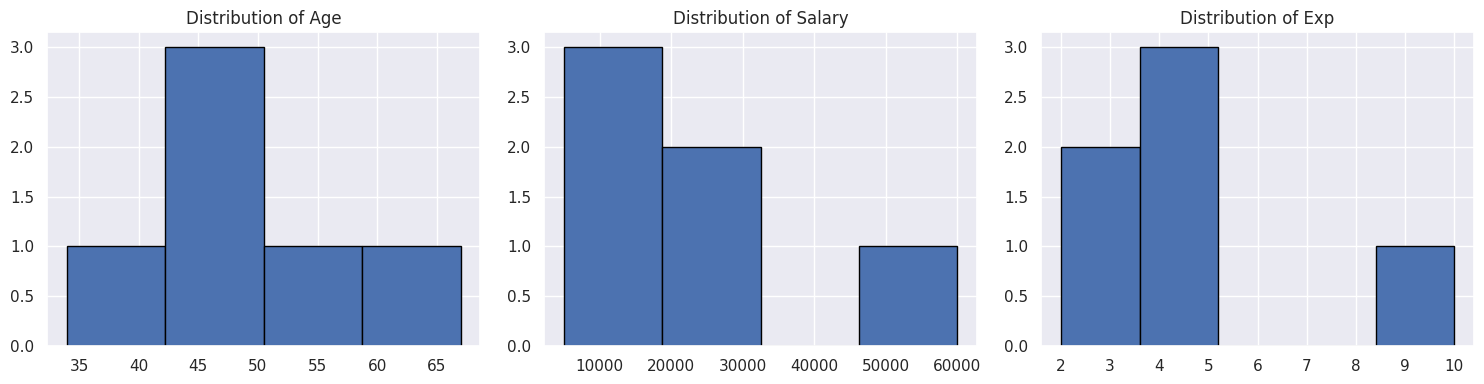

In [14]:
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(15, 4))
for ax, column in zip(axes, numeric_columns):
    ax.hist(clean_data[column].dropna(), bins='auto', edgecolor='black')
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [15]:
for column in categorical_columns:
    print(f"Counts for {column}:")
    display(clean_data[column].value_counts(dropna=False).to_frame("count"))

Counts for Name:


,count
Name,
Mike,1
Teddy,1
Umar,1
Jane,1
Uttam,1
Kim,1


Counts for Domain:


,count
Domain,
Datascience,1
Testing,1
Dataanalyst,1
Analytics,1
Statistics,1
NLP,1


Counts for Location:


,count
Location,
Bangalore,3
Mumbai,1
Hyderbad,1
Delhi,1


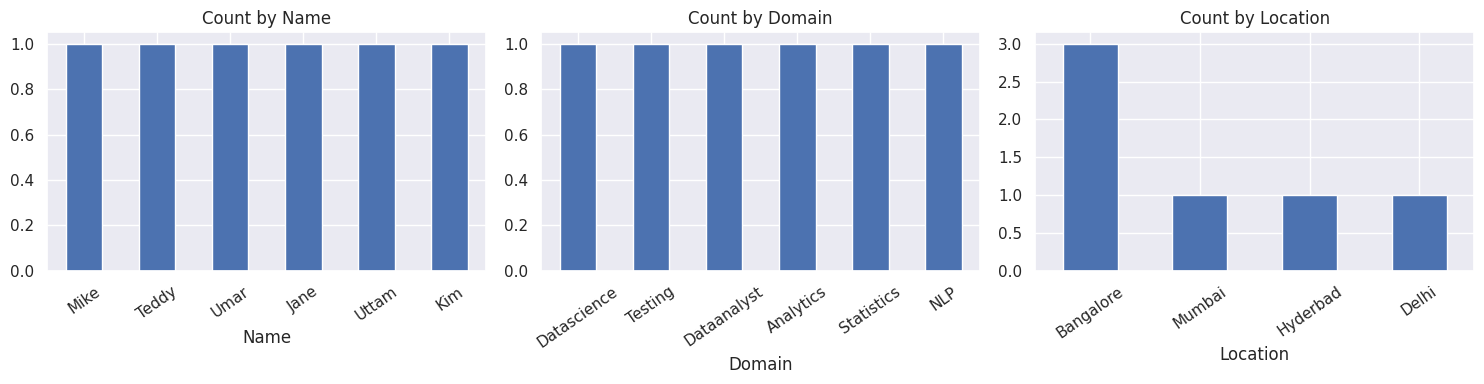

In [16]:
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 4))
for ax, column in zip(axes, categorical_columns):
    order = clean_data[column].value_counts().index
    clean_data[column].value_counts().reindex(order).plot(kind='bar', ax=ax)
    ax.set_title(f"Count by {column}")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 12. Bivariate analysis

Bivariate analysis explores the relationship between two variables. A scatter plot can show a pattern, but it does not prove that one variable causes another.

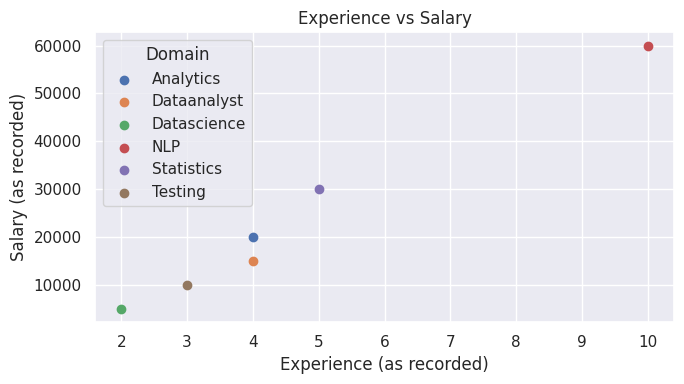

In [17]:
plt.figure(figsize=(7, 4))
for domain, group in clean_data.groupby("Domain"):
    plt.scatter(group["Exp"], group["Salary"], label=str(domain))
plt.legend(title="Domain")
plt.title("Experience vs Salary")
plt.xlabel("Experience (as recorded)")
plt.ylabel("Salary (as recorded)")
plt.tight_layout()
plt.show()

In [18]:
# Compare salary summaries across categories.
display(
    clean_data.groupby("Domain", dropna=False)["Salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

,count,mean,median,min,max
Domain,,,,,
NLP,1,60000.0,60000.0,60000,60000
Statistics,1,30000.0,30000.0,30000,30000
Analytics,1,20000.0,20000.0,20000,20000
Dataanalyst,1,15000.0,15000.0,15000,15000
Testing,1,10000.0,10000.0,10000,10000
Datascience,1,5000.0,5000.0,5000,5000


## 13. Correlation analysis

Pearson correlation describes linear association between numeric variables. With only a few rows, values can change dramatically and should not be treated as reliable evidence.

,Age,Salary,Exp
Age,1.000000,0.604574,0.544805
Salary,0.604574,1.000000,0.990555
Exp,0.544805,0.990555,1.000000


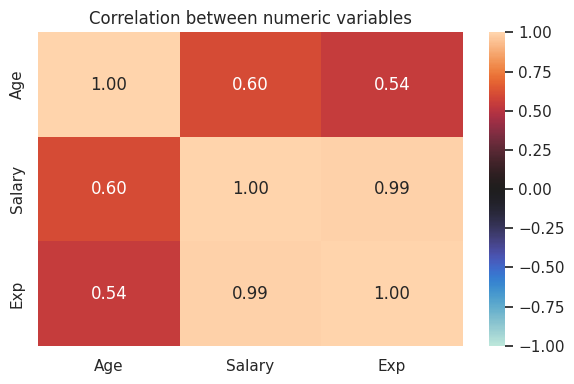

In [19]:
correlation = clean_data[numeric_columns].corr(method="pearson")
display(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation between numeric variables")
plt.tight_layout()
plt.show()

## 14. Outlier investigation with IQR

The IQR rule flags values outside `Q1 - 1.5 × IQR` and `Q3 + 1.5 × IQR`. A flagged value is a candidate for investigation, not an automatic reason to delete a row.

In [20]:
outlier_rows = []
for column in numeric_columns:
    q1 = clean_data[column].quantile(0.25)
    q3 = clean_data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (clean_data[column] < lower) | (clean_data[column] > upper)
    outlier_rows.append({
        "column": column, "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_fence": lower, "upper_fence": upper,
        "potential_outliers": int(mask.sum())
    })
display(pd.DataFrame(outlier_rows))

,column,Q1,Q3,IQR,lower_fence,upper_fence,potential_outliers
0,Age,46.25,53.75,7.5,35.0,65.0,2
1,Salary,11250.00,27500.00,16250.0,-13125.0,51875.0,1
2,Exp,3.25,4.75,1.5,1.0,7.0,1


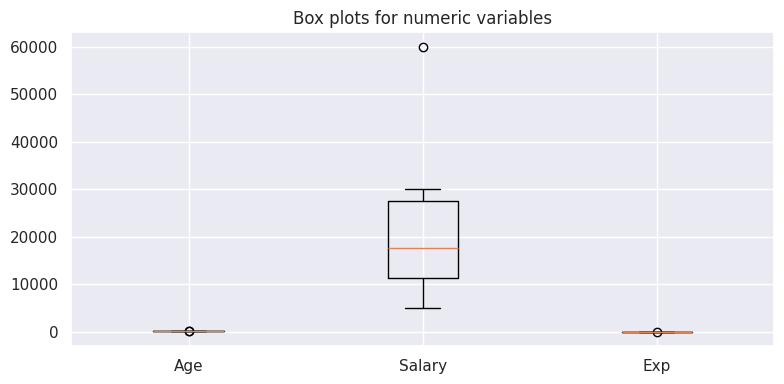

In [21]:
plt.figure(figsize=(8, 4))
plt.boxplot([clean_data[column].dropna() for column in numeric_columns], tick_labels=numeric_columns)
plt.title("Box plots for numeric variables")
plt.tight_layout()
plt.show()

## 15. Feature creation

A derived feature can make data easier to analyse. The thresholds below are illustrative; use domain knowledge to choose meaningful cut-offs.

In [22]:
clean_data["Experience_Level"] = pd.cut(
    clean_data["Exp"],
    bins=[-np.inf, 2, 5, np.inf],
    labels=["Beginner", "Intermediate", "Experienced"]
)
display(clean_data[["Exp", "Experience_Level"]])

,Exp,Experience_Level
0,2,Beginner
1,3,Intermediate
2,4,Intermediate
3,4,Intermediate
4,5,Intermediate
5,10,Experienced


## 16. Encoding categorical variables (preview)

One-hot encoding represents categories as indicator columns. It is useful in many modelling workflows, but the correct approach depends on the model and the data. Do not include identifiers or outcome-derived information without a clear reason.

In [23]:
encoded_preview = pd.get_dummies(
    clean_data[["Domain", "Location"]],
    columns=["Domain", "Location"],
    dtype=int
)
display(encoded_preview)

,Domain_Analytics,Domain_Dataanalyst,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Bangalore,Location_Delhi,Location_Hyderbad,Location_Mumbai
0,0,0,1,0,0,0,0,0,0,1
1,0,0,0,0,0,1,1,0,0,0
2,0,1,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0
5,0,0,0,1,0,0,0,1,0,0


## 17. Save cleaned data

The raw file remains unchanged. This cell writes the processed dataset to a new CSV file in the same folder.

In [24]:
output_path = "employee_cleaned_data_from_notebook.csv"
clean_data.to_csv(output_path, index=False)
print(f"Saved {output_path}")

Saved employee_cleaned_data_from_notebook.csv


## 18. Final quality summary

In [25]:
summary = {
    "rows": len(clean_data),
    "columns": len(clean_data.columns),
    "missing_cells": int(clean_data.isna().sum().sum()),
    "duplicate_rows": int(clean_data.duplicated().sum()),
}
display(pd.Series(summary, name="value").to_frame())
display(clean_data.head())

,value
rows,6
columns,7
missing_cells,0
duplicate_rows,0


,Name,Domain,Age,Location,Salary,Exp,Experience_Level
0,Mike,Datascience,34,Mumbai,5000,2,Beginner
1,Teddy,Testing,45,Bangalore,10000,3,Intermediate
2,Umar,Dataanalyst,50,Bangalore,15000,4,Intermediate
3,Jane,Analytics,50,Hyderbad,20000,4,Intermediate
4,Uttam,Statistics,67,Bangalore,30000,5,Intermediate


## 19. Interpretation checklist

Write a short answer in your own words after running the notebook:

1. Which columns had inconsistent or malformed values?
2. Which values became missing during numeric conversion?
3. Why was median/mode imputation used here, and what are its limitations?
4. Which variable distributions look skewed or contain possible outliers?
5. What relationship, if any, do you observe between experience and salary?
6. Why does correlation not establish causation?
7. What additional data or domain context would you need before making a business recommendation?
8. Which transformations must be fitted on training data only if you later build a predictive model?